In [66]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "monospace"

# Color Palette
NAVY: str = "#223D5A"
SEAFOAM: str = "#2B7371"
OCHRE: str = "#BBA358"
RED: str = "#B64541"

TESTS: str = "/home/abhans/Projects/acraft/tests"
TEST: int = max(os.listdir(TESTS), key=int)
PATH: str = f"{TESTS}/{TEST}"
# Model-specific Settings
BCLONE: str = f"{PATH}/bclone"
PPO: str = f"{PATH}/ppo"
print(f"Test: {TEST}")

Test: 04


# Behavior Clone Training Metric Analysis

In [67]:
data = pd.read_csv(f"{BCLONE}/metrics.csv")
data.head()

,Epoch,Loss:Train,Loss:Validation,Loss:Best:Validation
0,1,0.002661,0.001912,0.001912
1,2,0.001714,0.001567,0.001567
2,3,0.001483,0.001425,0.001425
3,4,0.001385,0.001357,0.001357
4,5,0.001321,0.001291,0.001291


In [68]:
# ------------------------ PLOT CONFIGURATIONS ------------------------
# (Axis Index, label, Key from Data, Color)
epochs = data["Epoch"].values
configPlot = [
    (0, "Train Loss", "Loss:Train", OCHRE),
    (1, "Validation Loss", "Loss:Validation", SEAFOAM),
]

[SYSTEM] Figure saved to: /home/abhans/Projects/acraft/tests/04/bclone/results.png


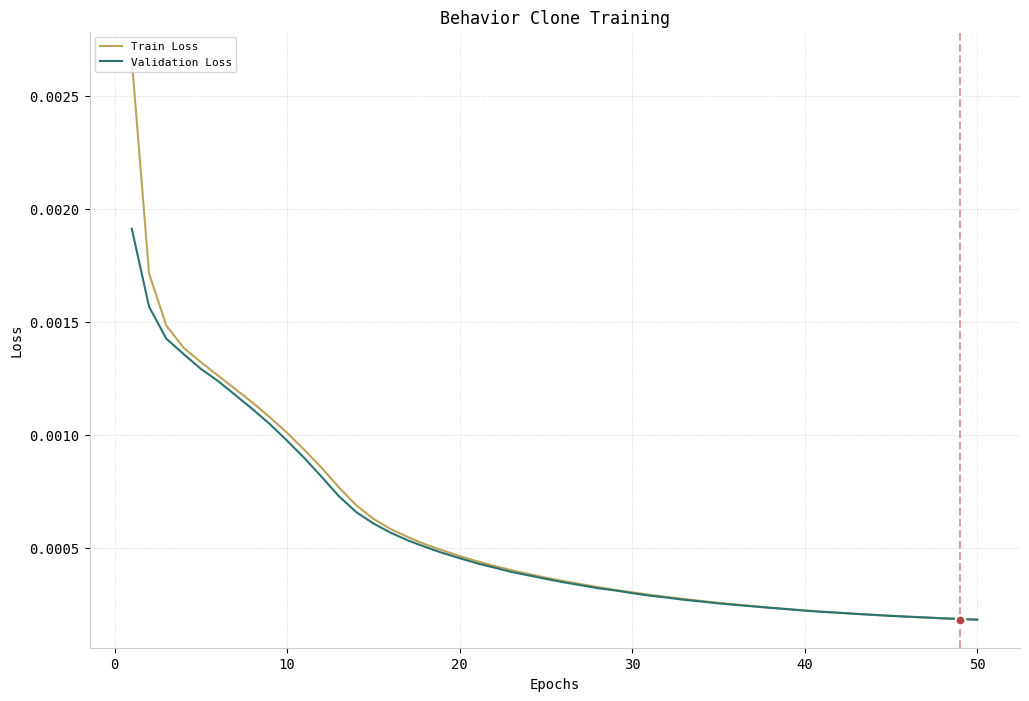

In [69]:
plt.figure(figsize=(12, 8))
# ------------------------ DRAW PLOT ------------------------
for idx, label, key, color in configPlot:
    plt.plot(
        epochs,
        data[key],
        color=color,
        linewidth=1.5,
        label=label
    )

# ------------------------------ BEST CKPT ------------------------------
bestEpoch = data["Loss:Validation"].idxmin()
bestloss = data.loc[bestEpoch, "Loss:Validation"]

plt.axvline(
    x=bestEpoch, 
    color=RED, 
    linestyle='--', 
    linewidth=1.5,
    alpha=.5,
)
plt.scatter(
    [bestEpoch], 
    [bestloss], 
    color=RED, 
    zorder=5, 
    s=50, 
    edgecolors="white", 
    linewidths=1.5
)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color("#CCCCCC")
ax.spines['bottom'].set_color("#CCCCCC")

# ------------------------ CLEANUP EMPTY SUBPLOT ------------------------
plt.title("Behavior Clone Training")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)
plt.legend(loc="upper left", fontsize=8)

plt.savefig(f"{BCLONE}/results.png", dpi=600)
print(f"[SYSTEM] Figure saved to: {f'{BCLONE}/results.png'}")

# PPO Training Metric Analysis

In [70]:
data = pd.read_csv(f"{PPO}/metrics.csv")
iterations = data["Iter"]

In [71]:
# ------------------------ PLOT CONFIGURATIONS ------------------------
# (Axis Index, title, Key from Data, Color)
configPlot = [
    (0, "Average Reward", "Average Reward", NAVY, True),
    (1, "Policy Loss (PPO)", "Loss:Policy", NAVY, True),
    (2, "Value Loss (Critic)","Loss:Value", SEAFOAM, True),
    (3, "Policy Entropy", "Entropy", OCHRE, False),
    (4, "Explained Variance", "Explained Variance", SEAFOAM, False),
    (5, "Moving Average Reward", "Moving Average Reward", OCHRE, True),
]

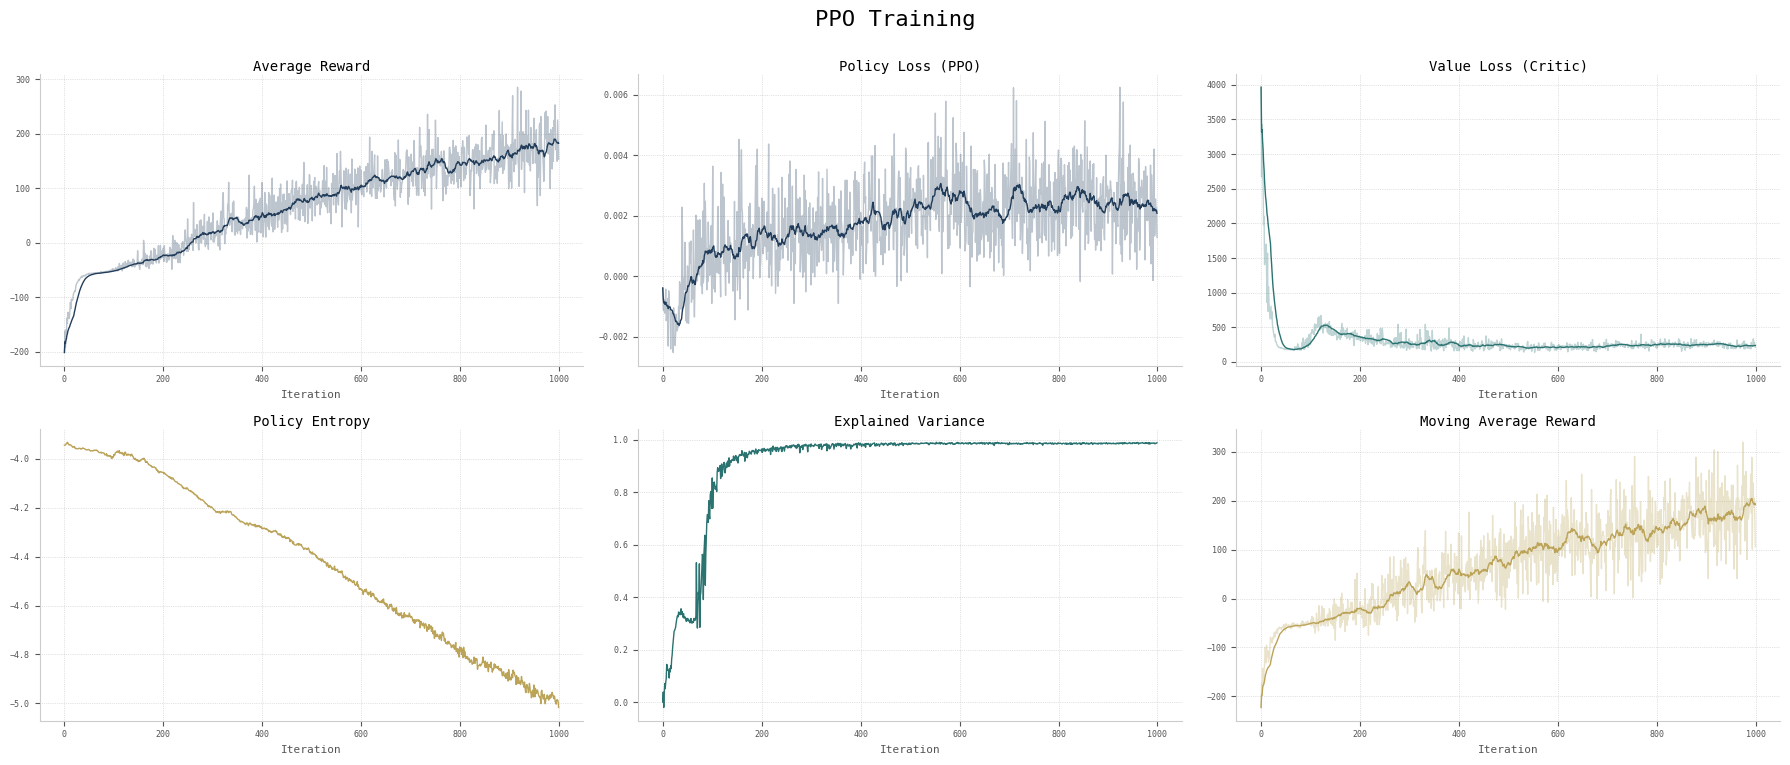

[SYSTEM] Figure saved to: /home/abhans/Projects/acraft/tests/04/results.png


In [72]:
# Set up the matplotlib figure (2 rows, 3 columns)
fig, axs = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("PPO Training", fontsize=16, fontweight="normal", y=0.95)

# Flatten axes array for easy iteration
axs = axs.flatten()

# ------------------------ DRAW PLOTS ------------------------
for idx, title, key, color, smooth in configPlot:
    ax = axs[idx]
    
    # Plot the smoothed curve if requested, otherwise plot raw data
    if smooth:
        # ---- Raw data with low opacity ----
        ax.plot(iterations, data[key], color=color, linewidth=1, alpha=0.3)
        smoothed = data[key].rolling(window=20, min_periods=1).mean()
        # ---- Smoothed curve ----
        ax.plot(iterations, smoothed, color=color, linewidth=1)
    else:
        ax.plot(iterations, data[key], color=color, linewidth=1)
    
    # Styling
    ax.set_title(title, fontsize=10, pad=2)
    ax.set_xlabel("Iteration", fontsize=8, color="#555555")
    ax.tick_params(colors="#555555", labelsize=6)
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("#CCCCCC")
    ax.spines['bottom'].set_color("#CCCCCC")

# ------------------------ CLEANUP EMPTY SUBPLOT ------------------------
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig(f"{PATH}/results.png", dpi=300)
print(f"[SYSTEM] Figure saved to: {f'{PATH}/results.png'}")